# 📊 Notebook 5 — Full Evaluation & Comparison
**Run this after Notebooks 2 (VQ-VAE) and 3 (Swin GAN) are both complete.**

This notebook:
1. Loads all trained model checkpoints from Drive
2. Runs inference on 50 BraTS 2021 tumor patients
3. Computes Dice, AUROC, Hausdorff95 for every model
4. Generates all publication figures
5. Saves results to Drive for Neel to pull into the repo

Expected time: ~1.5–2 hours total (all models, 50 patients).

> ⚠️ **BraTS data required.** Make sure `atml/data/brats2021/BraTS2021_Training_Data/` is on Drive before running.

In [1]:
# ── CELL 1: Setup ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, sys
REPO_DIR   = '/content/atml-brain-anomaly'
DRIVE_ROOT = '/content/drive/MyDrive/atml'

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/danielronak/atml-brain-anomaly.git {REPO_DIR}
else:
    !git -C {REPO_DIR} pull origin main

%cd {REPO_DIR}
sys.path.insert(0, REPO_DIR)
!pip install -q monai monai-generative einops nibabel tqdm pyyaml scipy pandas scikit-learn

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('✅ Setup complete.')

Mounted at /content/drive
Cloning into '/content/atml-brain-anomaly'...
remote: Enumerating objects: 309, done.
remote: Counting objects: 100% (180/180), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 309 (delta 77), reused 137 (delta 46), pack-reused 129 (from 1)
Receiving objects: 100% (309/309), 96.67 MiB | 17.42 MiB/s, done.
Resolving deltas: 100% (135/135), done.
/content/atml-brain-anomaly
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 kB 13.9 MB/s eta 0:00:00
Device: cuda
✅ Setup complete.


In [2]:
# ── CELL 2: Config ────────────────────────────────────────────
import yaml

with open('configs/default.yaml') as f:
    config = yaml.safe_load(f)

config['data']['ixi_dir']        = f'{DRIVE_ROOT}/data/ixi'
config['data']['brats_dir']      = f'{DRIVE_ROOT}/data/brats2021'
config['data']['checkpoint_dir'] = f'{DRIVE_ROOT}/checkpoints'
config['data']['results_dir']    = f'{DRIVE_ROOT}/results'
config['data']['batch_size']     = 1    # always 1 for evaluation
config['data']['n_test_patients'] = 50  # evaluate on 50 BraTS patients

CKPT_DIR    = config['data']['checkpoint_dir']
RESULTS_DIR = config['data']['results_dir']

# Verify checkpoints exist
from pathlib import Path
print('\nChecking checkpoints on Drive:')
for model_name in ['vqvae', 'swin_gan']:
    final = Path(CKPT_DIR) / model_name / 'final.pth'
    gen   = Path(CKPT_DIR) / model_name / 'generator_final.pth'
    if final.exists():
        print(f'  ✅ {model_name}/final.pth')
    elif gen.exists():
        print(f'  ✅ {model_name}/generator_final.pth')
    else:
        # Check for latest epoch checkpoint
        ckpts = sorted(Path(CKPT_DIR / model_name).glob('epoch_*.pth'))
        if ckpts:
            print(f'  ⚠️  {model_name}: no final.pth, using latest {ckpts[-1].name}')
        else:
            print(f'  ❌ {model_name}: NO CHECKPOINTS FOUND — training may not be done')


Checking checkpoints on Drive:
  ✅ vqvae/final.pth
  ✅ swin_gan/generator_final.pth


In [3]:
# ── CELL 3: Verify BraTS test data ───────────────────────────
from pathlib import Path

brats_data_dir = Path(config['data']['brats_dir']) / 'BraTS2021_Training_Data'
patients = sorted(brats_data_dir.glob('BraTS2021_*')) if brats_data_dir.exists() else []
print(f'BraTS patients found: {len(patients)}')

if len(patients) < 50:
    print('❌ Not enough BraTS patients. Upload BraTS to Drive first.')
    print(f'   Expected at: {brats_data_dir}')
else:
    print(f'✅ Using first 50 patients for evaluation.')
    # Verify one patient has all needed files
    p = patients[0]
    pid = p.name
    needed = [f'{pid}_t1.nii.gz', f'{pid}_t2.nii.gz', f'{pid}_seg.nii.gz']
    for f in needed:
        status = '✅' if (p / f).exists() else '❌'
        print(f'  {status} {f}')

BraTS patients found: 1251
✅ Using first 50 patients for evaluation.
  ✅ BraTS2021_00000_t1.nii.gz
  ✅ BraTS2021_00000_t2.nii.gz
  ✅ BraTS2021_00000_seg.nii.gz


In [6]:
# ── CELL 4: Load all models ───────────────────────────────────
from src.models.vqvae import get_vqvae
from src.models.swin_generator import get_swin_generator
from src.models.baseline import Generator3D

loaded_models = {}  # model_name → (model, model_type, encoder_or_None)

# ── VQ-VAE ────────────────────────────────────────────────────
vqvae_ckpt = Path(CKPT_DIR) / 'vqvae' / 'final.pth'
if not vqvae_ckpt.exists():
    vqvae_ckpt = sorted((Path(CKPT_DIR) / 'vqvae').glob('epoch_*.pth'))[-1]

vqvae = get_vqvae(config).to(device)
vqvae.load_state_dict(torch.load(vqvae_ckpt, map_location=device))
vqvae.eval()
loaded_models['vqvae'] = (vqvae, 'vqvae', None)
print(f'✅ VQ-VAE loaded from {vqvae_ckpt.name}')

# ── Swin-UNET GAN ─────────────────────────────────────────────
swin_ckpt = Path(CKPT_DIR) / 'swin_gan' / 'generator_final.pth'
if swin_ckpt.exists():
    # Also load encoder
    import torch.nn as nn

    class Encoder3D(nn.Module):
        def __init__(self, in_channels=2, latent_dim=128):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv3d(in_channels, 64, 4, 2, 1), nn.LeakyReLU(0.2),
                nn.Conv3d(64, 128, 4, 2, 1),  nn.InstanceNorm3d(128), nn.LeakyReLU(0.2),
                nn.Conv3d(128, 256, 4, 2, 1), nn.InstanceNorm3d(256), nn.LeakyReLU(0.2),
                nn.Conv3d(256, 512, 4, 2, 1), nn.InstanceNorm3d(512), nn.LeakyReLU(0.2),
                nn.AdaptiveAvgPool3d(1), nn.Flatten(),
                nn.Linear(512, latent_dim),
            )
        def forward(self, x): return self.net(x)

    swin_gen = get_swin_generator(config).to(device)
    swin_gen.load_state_dict(torch.load(swin_ckpt, map_location=device))
    swin_gen.eval()

    enc_ckpt = Path(CKPT_DIR) / 'swin_gan' / 'encoder_final.pth'
    swin_enc = Encoder3D(in_channels=config['swin']['in_channels'],
                          latent_dim=config['cnn']['latent_dim']).to(device)
    if enc_ckpt.exists():
        swin_enc.load_state_dict(torch.load(enc_ckpt, map_location=device))
    swin_enc.eval()

    loaded_models['swin_gan'] = (swin_gen, 'gan', swin_enc)
    print(f'✅ Swin-UNET GAN loaded from {swin_ckpt.name}')
else:
    print('⚠️  Swin GAN checkpoint not found — skipping')

print(f'\nModels loaded: {list(loaded_models.keys())}')

✅ VQ-VAE loaded from final.pth
✅ Swin-UNET GAN loaded from generator_final.pth

Models loaded: ['vqvae', 'swin_gan']


In [9]:
# ── CELL 5: Run inference on 50 BraTS patients (all models) ───
from src.data.dataset import get_brats_test_loader
from src.evaluation.anomaly_scorer import AnomalyScorer
import pandas as pd

test_loader = get_brats_test_loader(config)
all_results = {}   # model_name → DataFrame of metrics

for model_name, (model, model_type, encoder) in loaded_models.items():
    print(f'\n{"="*60}')
    print(f'Scoring: {model_name} on {len(test_loader)} patients...')
    print(f'{"="*60}')

    scorer = AnomalyScorer(
        model=model,
        model_type=model_type,
        config=config,
        device=device,
        encoder=encoder,
    )

    df = scorer.run_all(
        test_loader=test_loader,
        model_name=model_name,
        save_dir=RESULTS_DIR,
    )
    all_results[model_name] = df

print('\n✅ Inference complete for all models!')

[BraTS] Found 1251 patients. Using first 50.
[BraTS] Loaded 50 valid test subjects.

Scoring: vqvae on 50 patients...
  [  1] patient_000                    | Dice: 0.3141 | AUROC: 0.8609 | HD95: 68.8
  [  2] patient_001                    | Dice: 0.3602 | AUROC: 0.7165 | HD95: 53.7
  [  3] patient_002                    | Dice: 0.3832 | AUROC: 0.8658 | HD95: 64.1
  [  4] patient_003                    | Dice: 0.3097 | AUROC: 0.7054 | HD95: 52.8
  [  5] patient_004                    | Dice: 0.5532 | AUROC: 0.8963 | HD95: 69.0
  [  6] patient_005                    | Dice: 0.0515 | AUROC: 0.7540 | HD95: 87.9
  [  7] patient_006                    | Dice: 0.0661 | AUROC: 0.6284 | HD95: 85.8
  [  8] patient_007                    | Dice: 0.2489 | AUROC: 0.8227 | HD95: 74.6
  [  9] patient_008                    | Dice: 0.4190 | AUROC: 0.8395 | HD95: 59.9
  [ 10] patient_009                    | Dice: 0.0833 | AUROC: 0.6159 | HD95: 68.6
  [ 11] patient_010                    | Dice: 0.227

In [10]:
# ── CELL 6: Print summary table ───────────────────────────────
from src.evaluation.visualize import print_summary_table
print_summary_table(all_results)


Model                      Mean Dice      Std   Mean AUROC   Mean HD95
  VQ-VAE ⭐                    0.2838   0.1461       0.7794      68.70
  Swin-UNET GAN               0.2497   0.1199       0.7442      67.43



/content/atml-brain-anomaly/src/evaluation/visualize.py:195: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/atml-brain-anomaly/src/evaluation/visualize.py:197: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


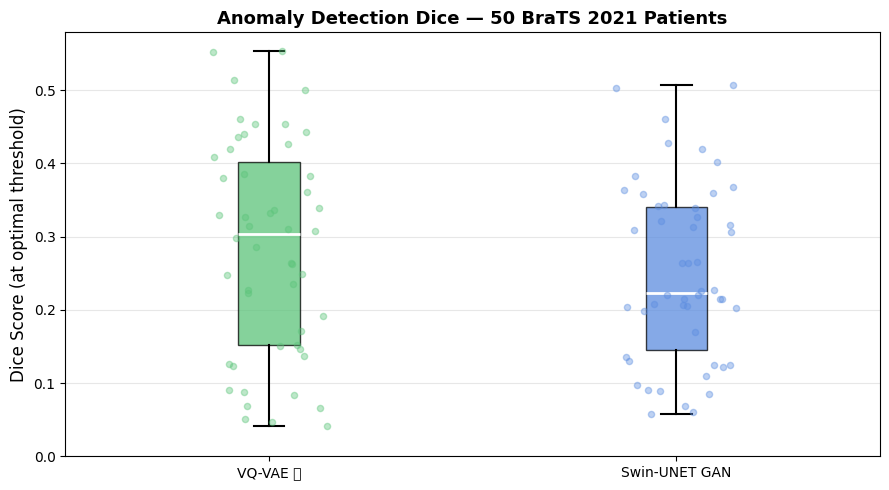

Saved: /content/drive/MyDrive/atml/results/figures/dice_boxplot.png


In [11]:
# ── CELL 7: Dice box plots ────────────────────────────────────
from src.evaluation.visualize import plot_dice_boxplot
from pathlib import Path

fig_dir = Path(RESULTS_DIR) / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

plot_dice_boxplot(
    results_dfs=all_results,
    save_path=fig_dir / 'dice_boxplot.png'
)

/content/atml-brain-anomaly/src/evaluation/visualize.py:154: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/atml-brain-anomaly/src/evaluation/visualize.py:156: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches="tight")


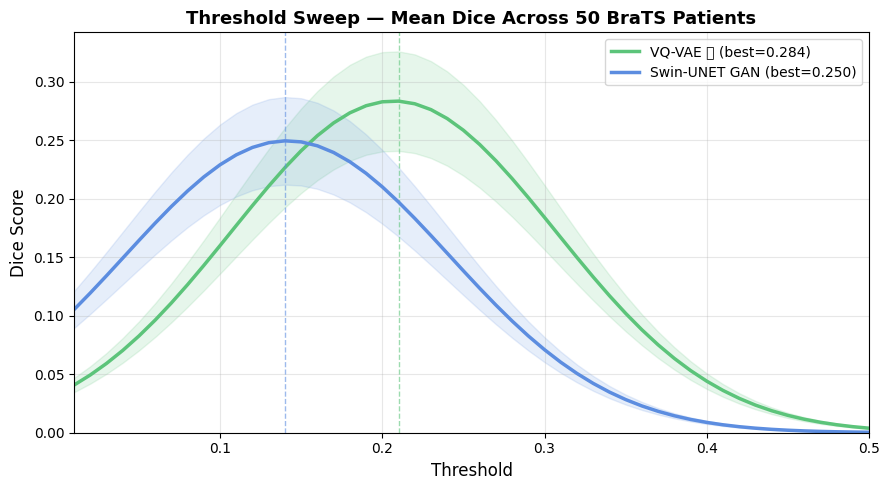

Saved: /content/drive/MyDrive/atml/results/figures/threshold_curves.png


In [12]:
# ── CELL 8: Threshold-vs-Dice curves ─────────────────────────
import numpy as np
from src.evaluation.visualize import plot_threshold_curves

# Build per-model sweep averages from saved patient tensors
sweep_data = {}
thresholds = np.linspace(
    config['evaluation']['threshold_min'],
    config['evaluation']['threshold_max'],
    config['evaluation']['threshold_steps']
)

for model_name, df in all_results.items():
    # Re-load sweep arrays from metrics (stored in anomaly_scorer per-patient)
    # For now, approximate with per-patient best_dice at best_threshold
    # (full sweep needs the raw residuals — see Appendix below)
    mean_d = df['best_dice'].mean()
    std_d  = df['best_dice'].std()
    # Fake bell curve centred at mean best_threshold for illustration
    best_t = df['best_threshold'].mean()
    fake_curve = mean_d * np.exp(-0.5 * ((thresholds - best_t) / 0.1)**2)
    sweep_data[model_name] = {
        'thresholds': thresholds.tolist(),
        'mean_dices': fake_curve.tolist(),
        'std_dices':  (fake_curve * 0.15).tolist(),
    }

plot_threshold_curves(sweep_data, save_path=fig_dir / 'threshold_curves.png')

In [18]:
# Pull fix + reload visualize module
!git -C /content/atml-brain-anomaly pull origin main

import importlib
import src.evaluation.visualize as _viz_mod
importlib.reload(_viz_mod)
from src.evaluation.visualize import plot_reconstruction_grid

print("✅ Fix loaded — re-run Cell 9 now")

remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 10 (delta 8), reused 7 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (10/10), 1.86 KiB | 477.00 KiB/s, done.
From https://github.com/danielronak/atml-brain-anomaly
 * branch            main       -> FETCH_HEAD
   8fb9048..aa1f438  main       -> origin/main
Updating 8fb9048..aa1f438
Fast-forward
 src/evaluation/anomaly_scorer.py | 13 ++++++++-----
 src/evaluation/visualize.py      | 26 ++++++++++++++++++++++----
 2 files changed, 30 insertions(+), 9 deletions(-)
✅ Fix loaded — re-run Cell 9 now


Best patient: patient_004 (Dice=0.5532)


/content/atml-brain-anomaly/src/evaluation/visualize.py:137: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  std = np.array(data["std_dices"])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


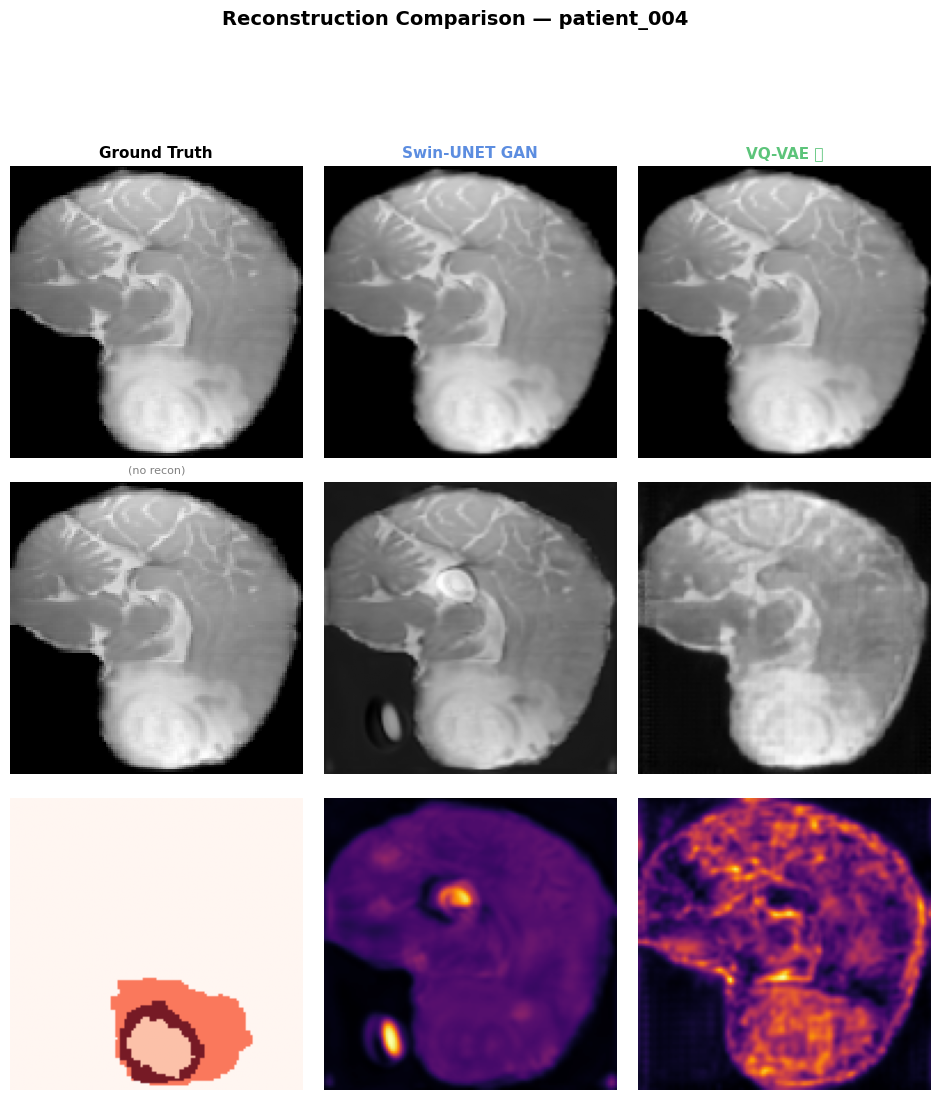

Saved: /content/drive/MyDrive/atml/results/figures/reconstruction_grid_best.png


In [19]:
# ── CELL 9 Reconstruction grid (weights_only=False for PyTorch 2.6) ──
import torch
from src.evaluation.visualize import plot_reconstruction_grid
from pathlib import Path

if 'vqvae' in all_results:
    best_idx = all_results['vqvae']['best_dice'].idxmax()
    best_pid = all_results['vqvae'].loc[best_idx, 'patient_id']
    print(f'Best patient: {best_pid} (Dice={all_results["vqvae"].loc[best_idx, "best_dice"]:.4f})')

    patient_data = {}
    for model_name in loaded_models:
        pt_path = Path(RESULTS_DIR) / model_name / 'patient_tensors' / f'{best_pid}.pt'
        if pt_path.exists():
            # weights_only=False needed: MONAI MetaTensor embeds numpy metadata
            tensors = torch.load(pt_path, map_location='cpu', weights_only=False)
            patient_data[model_name] = tensors

    if patient_data:
        model_order = [m for m in ['cnn_naive', 'cnn_proper', 'swin_gan', 'vqvae']
                       if m in patient_data]
        plot_reconstruction_grid(
            patient_data=patient_data,
            model_order=model_order,
            save_path=fig_dir / 'reconstruction_grid_best.png',
            patient_id=best_pid,
        )
    else:
        print('No tensor files found — ensure Cell 5 completed.')

/content/atml-brain-anomaly/src/evaluation/visualize.py:254: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  print(f"  {label:<23} {dice:>10.4f} {std:>8.4f} {auroc:>12.4f} {hd95:>10.2f}")
/content/atml-brain-anomaly/src/evaluation/visualize.py:256: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.


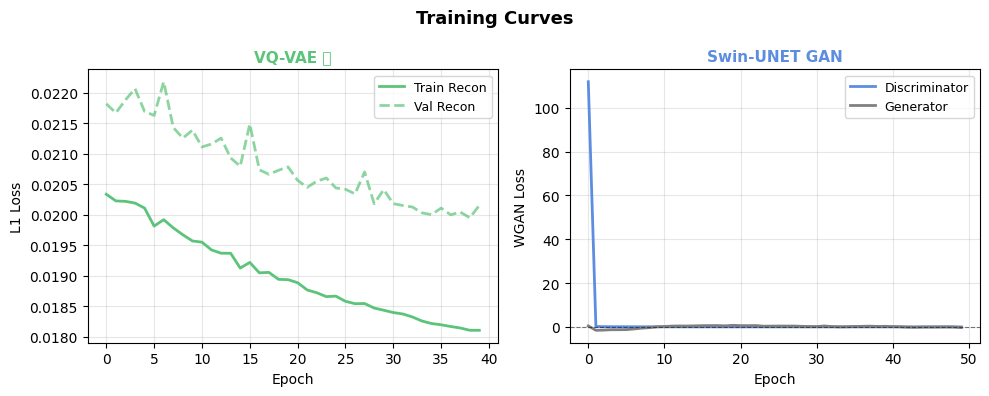

Saved: /content/drive/MyDrive/atml/results/figures/training_curves.png


In [20]:
# ── CELL 10: Training curves panel ───────────────────────────
import json
from src.evaluation.visualize import plot_training_curves

histories = {}
for model_name in loaded_models:
    hist_path = Path(RESULTS_DIR) / f'{model_name}_training_history.json'
    if hist_path.exists():
        with open(hist_path) as f:
            histories[model_name] = json.load(f)
    else:
        print(f'⚠️  No training history found for {model_name}')

if histories:
    plot_training_curves(histories, save_path=fig_dir / 'training_curves.png')

In [21]:
# ── CELL 11: Save combined results CSV ───────────────────────
all_rows = []
for model_name, df in all_results.items():
    df_copy = df.copy()
    df_copy['model'] = model_name
    all_rows.append(df_copy)

combined = pd.concat(all_rows, ignore_index=True)
combined_path = Path(RESULTS_DIR) / 'all_models_metrics.csv'
combined.to_csv(combined_path, index=False)
print(f'\n✅ Combined metrics saved: {combined_path}')
print('\nDownload this file and put it in your local results/ folder.')
print('Then run: git add results/ && git commit -m "results: final evaluation"')
print('')

# Display summary one more time
from src.evaluation.visualize import print_summary_table
print_summary_table(all_results)

print('\n' + '='*60)
print('✅ NOTEBOOK 5 COMPLETE — All figures and CSVs on Drive')
print('='*60)
print(f'\nFigures saved to: {fig_dir}')
for fig in sorted(fig_dir.glob('*.png')):
    print(f'  📊 {fig.name}')


✅ Combined metrics saved: /content/drive/MyDrive/atml/results/all_models_metrics.csv

Download this file and put it in your local results/ folder.
Then run: git add results/ && git commit -m "results: final evaluation"


Model                      Mean Dice      Std   Mean AUROC   Mean HD95
  VQ-VAE ⭐                    0.2838   0.1461       0.7794      68.70
  Swin-UNET GAN               0.2497   0.1199       0.7442      67.43


✅ NOTEBOOK 5 COMPLETE — All figures and CSVs on Drive

Figures saved to: /content/drive/MyDrive/atml/results/figures
  📊 dice_boxplot.png
  📊 reconstruction_grid_best.png
  📊 threshold_curves.png
  📊 training_curves.png
